# **Análisis y Procesamiento de Señales**
## Trabajo Práctico Final: *Detección de Potenciales Tardíos Ventriculares (ENTREGA PARCIAL)*
### Salgado, Victoria Jazmín 


Objetivo: Desarrollo de algoritmo para detección de VLPs según lineamientos propuestos por la AHA (*American Heart Association*). El algoritmo deberá funcionar con cualquier registro .hea pertenenciente a la base de datos seleccionada. 
El .hea contiene la metadata necesaria para procesar la información contenida en el .dat. 
Se pide seleccionar el .hea, permitiendo utilizar la librería desarrollada para el procesamiento del database de Physionet, WFDB
(https://physionet.org/content/wfdb-python/4.1.0/)76)

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import wfdb
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as signal

import os
from tkinter import filedialog
import funciones_TPF as func

El siguiente código permite abrir una ventana emergente (windows) para seleccionar el archivo .hea del paciente que se desea analizar.

In [3]:
def leer_registro(paciente) :
    
    record = wfdb.rdrecord(paciente)
    # columnas 12, 13 y 14 (son vx, vy, vz en Frank - ver .hea)
    frank_x = record.p_signal[:, 12]
    frank_y = record.p_signal[:, 13]
    frank_z = record.p_signal[:, 14]
    return frank_x, frank_y, frank_z

Seleccionar el archivo .hea del paciente...
Cargado con éxito: s0028lre


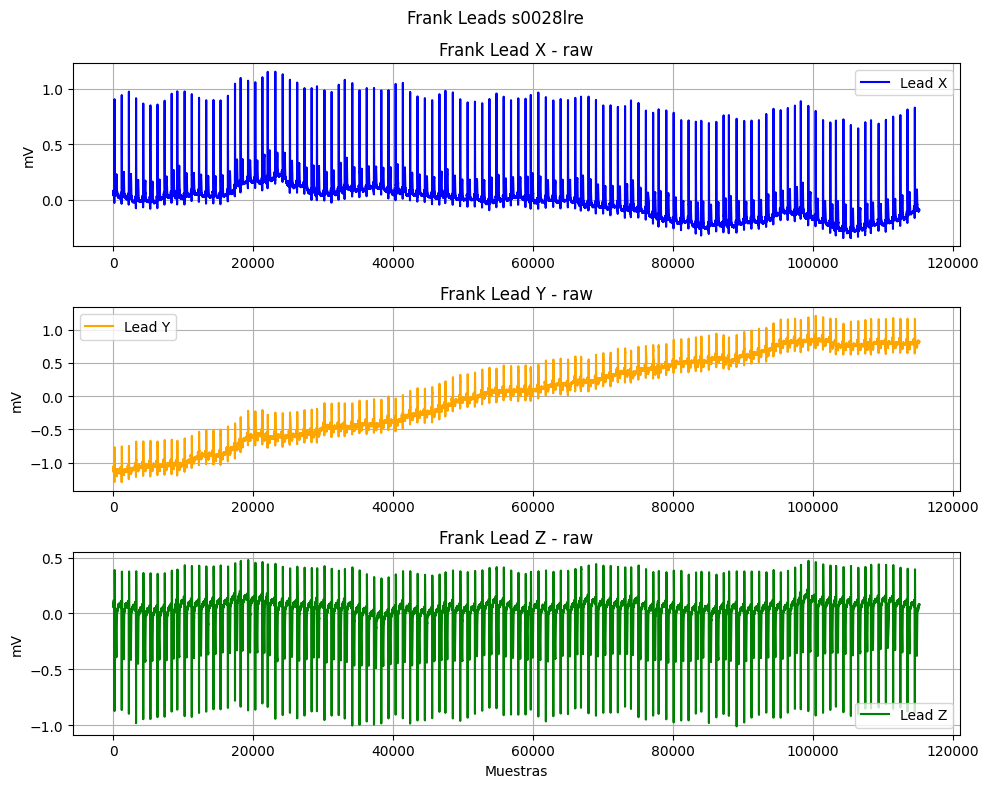

In [4]:
#%% IMPORTAR PACIENTE - FRANK LEADS XYZ

print("Seleccionar el archivo .hea del paciente...")
ruta_h = filedialog.askopenfilename(
    title="Seleccionar Registro ECG",
    filetypes=[("Archivos PhysioNet", "*.hea")]
)

if ruta_h:
    #Sacar el ".hea" del final (wfdb)
    ruta_limpia = os.path.splitext(ruta_h)[0]

    frank_x, frank_y, frank_z = func.leer_registro(ruta_limpia)
    
    print(f"Cargado con éxito: {os.path.basename(ruta_limpia)}")
    
    plt.figure(figsize=(10, 8))

    #Lead X 
    plt.subplot(3, 1, 1)
    plt.plot(frank_x, label='Lead X', color='blue')
    plt.title('Frank Lead X - raw')
    plt.legend()
    plt.grid(True)
    plt.ylabel('mV')

    #Lead Y
    plt.subplot(3, 1, 2)
    plt.plot(frank_y, label='Lead Y', color='orange')
    plt.title('Frank Lead Y - raw')
    plt.grid(True)
    plt.ylabel('mV')
    plt.legend()

    #Lead Z
    plt.subplot(3, 1, 3)
    plt.title('Frank Lead Z - raw')
    plt.plot(frank_z, label='Lead Z', color='green')
    plt.grid(True)
    plt.ylabel('mV')
    plt.legend()

    plt.suptitle(f"Frank Leads {os.path.basename(ruta_limpia)}")
    plt.xlabel("Muestras")
    plt.tight_layout() 
    plt.grid(True)
    plt.ylabel('mV')
    plt.show()
    
else:
    print("No se seleccionó ningún archivo.")

Se continúa por adaptar el algoritmo de Pan-Tompkins a este trabajo, de manera de detectar los latidos. Como señal "trigger" se utilizará el Frank Lead X.

Se comienza por eliminar posibles NaNs de la señal y luego se implementa un filtro bidireccional butterworth, minimizando la introducción de ringing en las frecuencias de interés gracias a la máxima planicidad que ofrece en la banda de paso y eliminando la distorsión de fase (filtfilt). Por ser un filtro pasabanda, se eliminan las bajas frecuencias que pueden corresponder a baseline wander o altas frecuencias que pueden provenir de otras fuentes fisiológicas. Cabe destacar que este filtrado agresivo se implementa obteniendo una señal que sólo se utilizará para detectar los latidos, luego se regresa a la señal original para continuar con el procesado.

Tomando como referencia el algoritmo original que trabaja con una $fs$ de 200Hz, se adaptó la cantidad de muestras necesarias para el filtro de integración por ventana movil, utilizando 150 muestras dado que en este estudio (HRECG) la $fs$ es de 1000Hz. 

El algoritmo original de Pan-Tompkins está diseñado para el procesamiento en tiempo real; sin embargo por estar trabajando con señales grabadas, para continuar con el procesado se plantea un umbral dado por el percentil que deja una determinada amplitud por debajo. Así fue posible hallar las muestras correspondientes a los picos R sobre la señal post integración por ventana móvil, pidiendo que se supere el umbral descrito y ademas una separación de 300ms considerada como período refractario, en el que no pueden haber nuevos latidos. 

In [5]:
def deteccion_pan_tompkins(paciente):
    
    fs = 1000
    recordh1 = wfdb.rdrecord(paciente)
    h1 = recordh1.p_signal[:,12]
    t = np.arange(len(h1)) / fs
    
    # Sacar NaN
    x, = np.where(np.isnan(h1))
    if len(x) != 0:
        print('NaNs in ECG: ' + str(x))
    for i in x:
        h1[i] = h1[i - 1]
        
    # Filter ECG
    sos_ecg = signal.butter(4, [5, 15], btype='bp', analog=False, output='sos', fs=fs)
    ecg_ff = signal.sosfiltfilt(sos_ecg, h1)
    
    # Derivada 5 puntos
    T = 1.0 / fs
    coeficientes_b = np.array([1, 2, 0, -2, -1])
    b = coeficientes_b * (1.0 / (8.0 * T))
    a = 1.0 
    
    senal_derivada = signal.lfilter(b, [a], ecg_ff)
    
    # Corrección delay 2 muestras
    senal_derivada = np.append(senal_derivada[2:], [0, 0])
     
    # Squaring function
    senal_cuadrada = senal_derivada ** 2
    
    # Moving window integration
    N = 150 # Para fs=1000
    a_mw = 1
    b_mw = np.ones(N) / N
    
    senal_integrada = signal.lfilter(b_mw, a_mw, senal_cuadrada)
    
    # Detección inicial 
    umbral = np.percentile(senal_integrada, 80)
    peaks, _ = signal.find_peaks(senal_integrada, height=umbral, distance=300)

    #Búsqueda del Máximo Local para corregir el retardo 
    picos_corregidos = []
    
    margen_atras = 100 
    margen_adelante = 20 
    
    for p in peaks:
        inicio = max(0, p - margen_atras)
        fin = min(len(h1), p + margen_adelante)
        
        segmento = h1[inicio:fin]
        
        if len(segmento) > 0:
            pos_relativa = np.argmax(segmento)
            
            pos_absoluta = inicio + pos_relativa
            picos_corregidos.append(pos_absoluta)
            
    peaks_finales = np.array(picos_corregidos)

    return h1, ecg_ff, t, senal_derivada, senal_cuadrada, senal_integrada, peaks_finales
        

Luego de una primera iteración, una vez que se tuvo andando el prototipo del algoritmo, se observó que no se correspondía la detección obtenida con el pico R buscado. 

Ésto se pudo explicar gracias al retardo de grupo introducido por el filtro de ventana móvil, que se determina de manera teórica como $\frac{N-1}{2}$.  Se establece entonces una ventana de 100 muestras hacia atras (para asegurarse de cubrir el retardo, que sería en este caso de ~75 muestras) a partir de la detección anterior (*peaks*), en la cual se buscó la muestra correspondiente a la amplitud máxima, obteniendo satisfactoriamente los picos R en el lead Frank X.

Se grafican a continuación las etapas del algoritmo de detección de latidos:

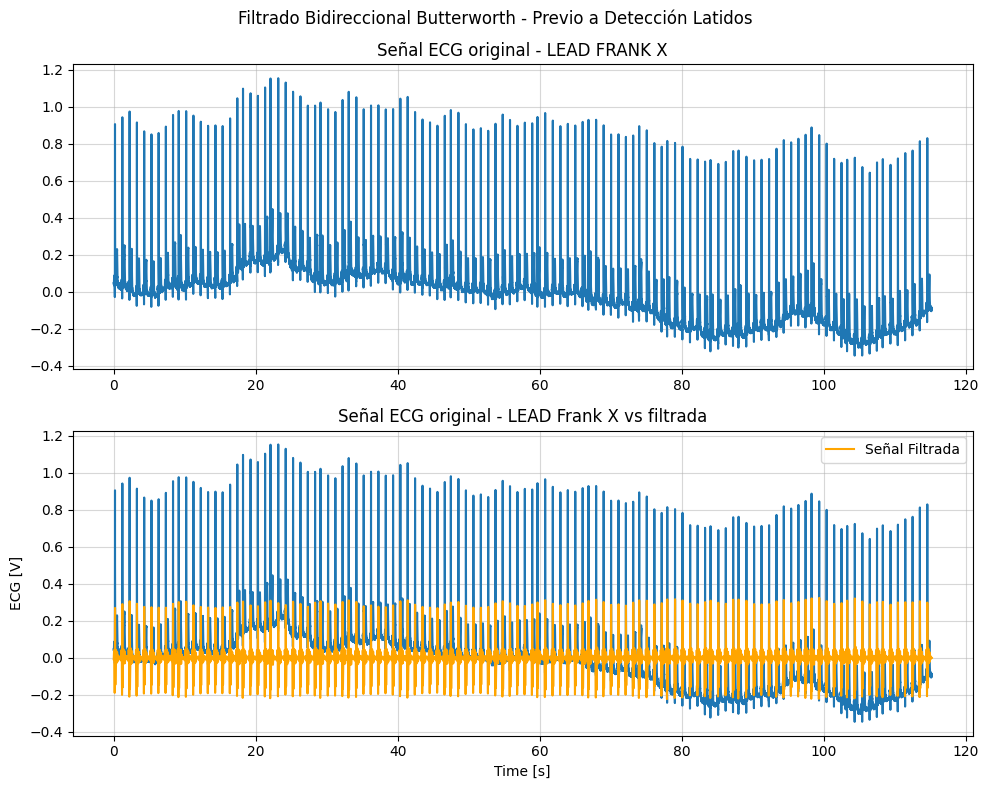

In [6]:
#%% DETECCION LATIDOS 

h1, ecg_ff, t, senal_derivada, senal_cuadrada, senal_integrada, peaks_finales = func.deteccion_pan_tompkins(ruta_limpia)

plt.figure(figsize=(10,8))
plt.suptitle('Filtrado Bidireccional Butterworth - Previo a Detección Latidos')

plt.subplot(2,1,1)
plt.title('Señal ECG original - LEAD FRANK X')
plt.plot(t, h1, label='Señal Original')
plt.grid(True, alpha=0.5)

plt.subplot(2,1,2)
plt.title('Señal ECG original - LEAD Frank X vs filtrada')
plt.plot(t, h1)
plt.plot(t, ecg_ff, color = 'orange', label='Señal Filtrada')

plt.xlabel('Time [s]')
plt.ylabel('ECG [V]')
plt.grid(True, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


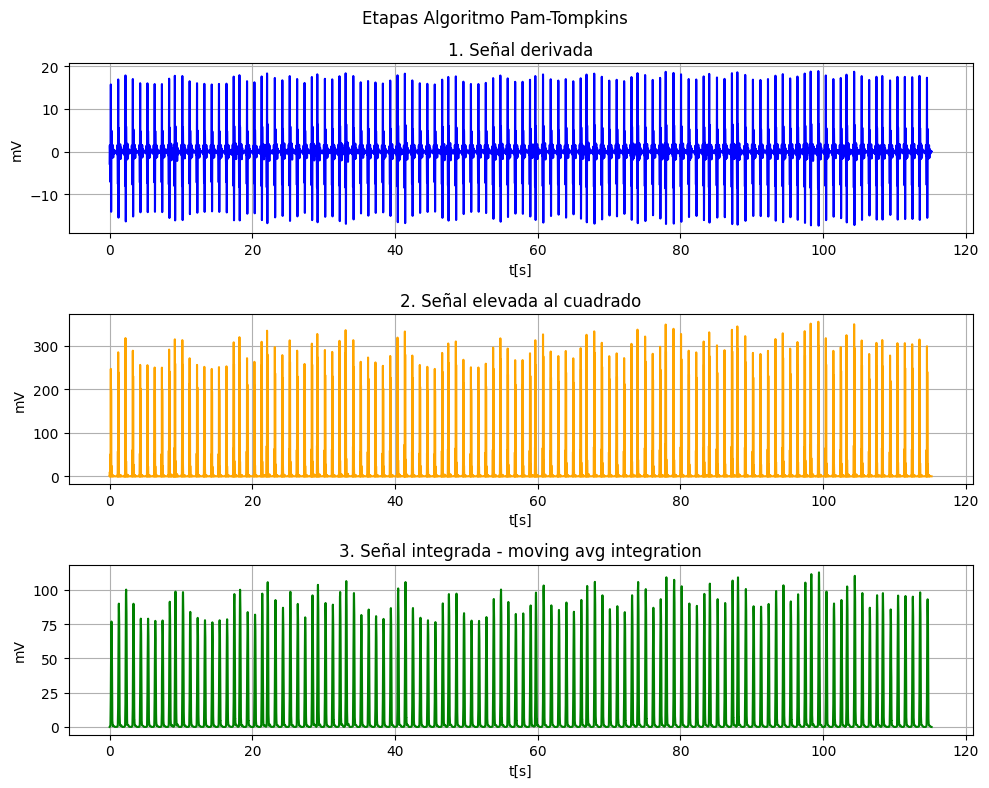

In [7]:
#%% PAN-TOMPKINS

plt.figure(figsize=(10, 8))
plt.suptitle('Etapas Algoritmo Pam-Tompkins')

plt.subplot(3, 1, 1)
plt.title('1. Señal derivada')
plt.plot(t, senal_derivada, color='blue')
plt.grid(True)
plt.ylabel('mV')
plt.xlabel('t[s]')

plt.subplot(3, 1, 2)
plt.title('2. Señal elevada al cuadrado')
plt.plot(t, senal_cuadrada, color='orange')
plt.grid(True)
plt.ylabel('mV')
plt.xlabel('t[s]')

plt.subplot(3, 1, 3)
plt.title('3. Señal integrada - moving avg integration')
plt.plot(t, senal_integrada, color='green')
plt.grid(True)
plt.ylabel('mV')
plt.xlabel('t[s]')

plt.tight_layout()
plt.show()

Text(0, 0.5, 'mV')

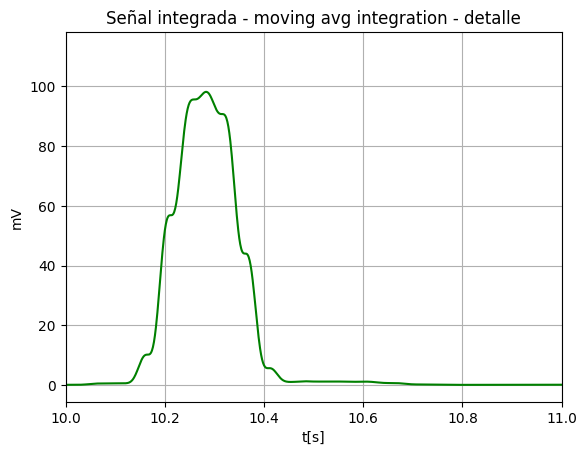

In [8]:
#detalle moving average integration
plt.figure()
plt.title('Señal integrada - moving avg integration - detalle')
plt.plot(t, senal_integrada, color='green')
plt.grid(True)
plt.xlim([10,11])
plt.xlabel('t[s]')
plt.ylabel('mV')

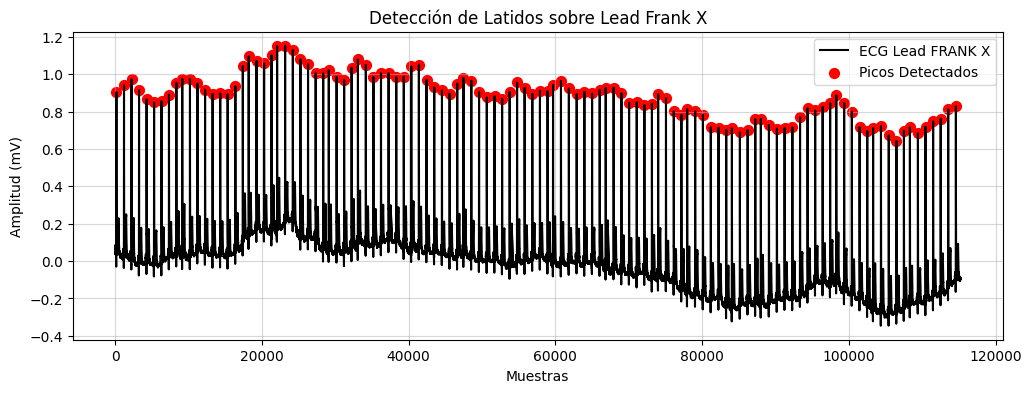

In [9]:
#%% latidos detectados sobre FRANK X (trigger)

plt.figure(figsize=(12, 4)) 
plt.plot(h1, color='black', label='ECG Lead FRANK X')

plt.scatter(peaks_finales, h1[peaks_finales], color='red', marker='o', s=50, label='Picos Detectados')

plt.title('Detección de Latidos sobre Lead Frank X')
plt.xlabel('Muestras')
plt.ylabel('Amplitud (mV)')
plt.legend()
plt.grid(True, alpha=0.5) 

plt.show()


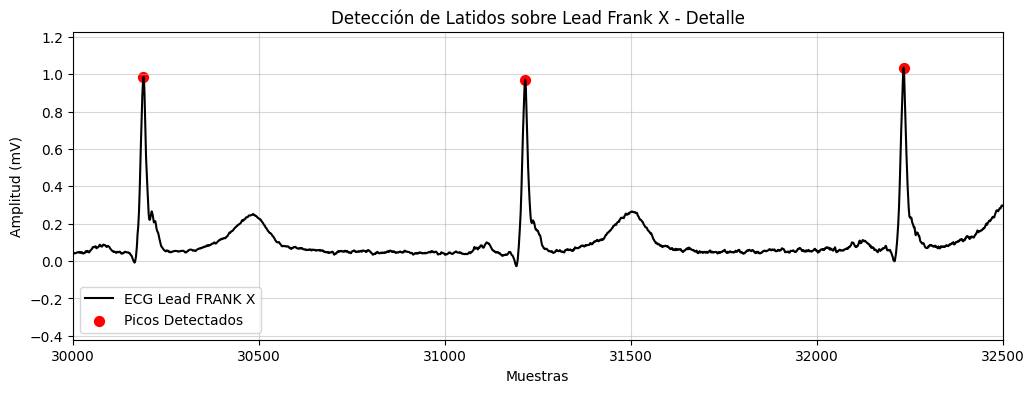

In [10]:
plt.figure(figsize=(12, 4)) 
plt.plot(h1, color='black', label='ECG Lead FRANK X')

plt.scatter(peaks_finales, h1[peaks_finales], color='red', marker='o', s=50, label='Picos Detectados')

plt.title('Detección de Latidos sobre Lead Frank X - Detalle')
plt.xlabel('Muestras')
plt.xlim([30000,32500])
plt.ylabel('Amplitud (mV)')
plt.legend()
plt.grid(True, alpha=0.5) 

plt.show()

Se observa la correcta detección de los picos R, y por consiguiente de los latidos. 
Contando con los mismos, es posible realizar la remoción del ruido de linea de base. Para hacerlo se eligió el método de splines cúbicos. 
Se consideró también el método de  mediana, pero se determinó que no resulta adecuado para este trabajo ya que se basa en las duraciones tipicas de los segmentos de ECG. Como se estará tratando con ECGs posiblemente anormales, se debe seleccionar un método robusto frente a estas variaciones. Splines cúbicos resulta más adecuado ya que se basa en la determinación de puntos isoeléctricos presentes en cualquier ECG. 

In [11]:
from scipy.interpolate import CubicSpline

def remover_linea_base_spline(senal, picos_r, offset_ms=70, fs=1000):
    offset_muestras = int(offset_ms * fs / 1000)
    nodos_idx = picos_r - offset_muestras
    
    amplitudes_nodos = senal[nodos_idx]
    
    cs = CubicSpline(nodos_idx, amplitudes_nodos)
    
    indices_totales = np.arange(len(senal))
    linea_base_estimada = cs(indices_totales)
    
    senal_limpia = senal - linea_base_estimada
    
    return senal_limpia, linea_base_estimada, nodos_idx

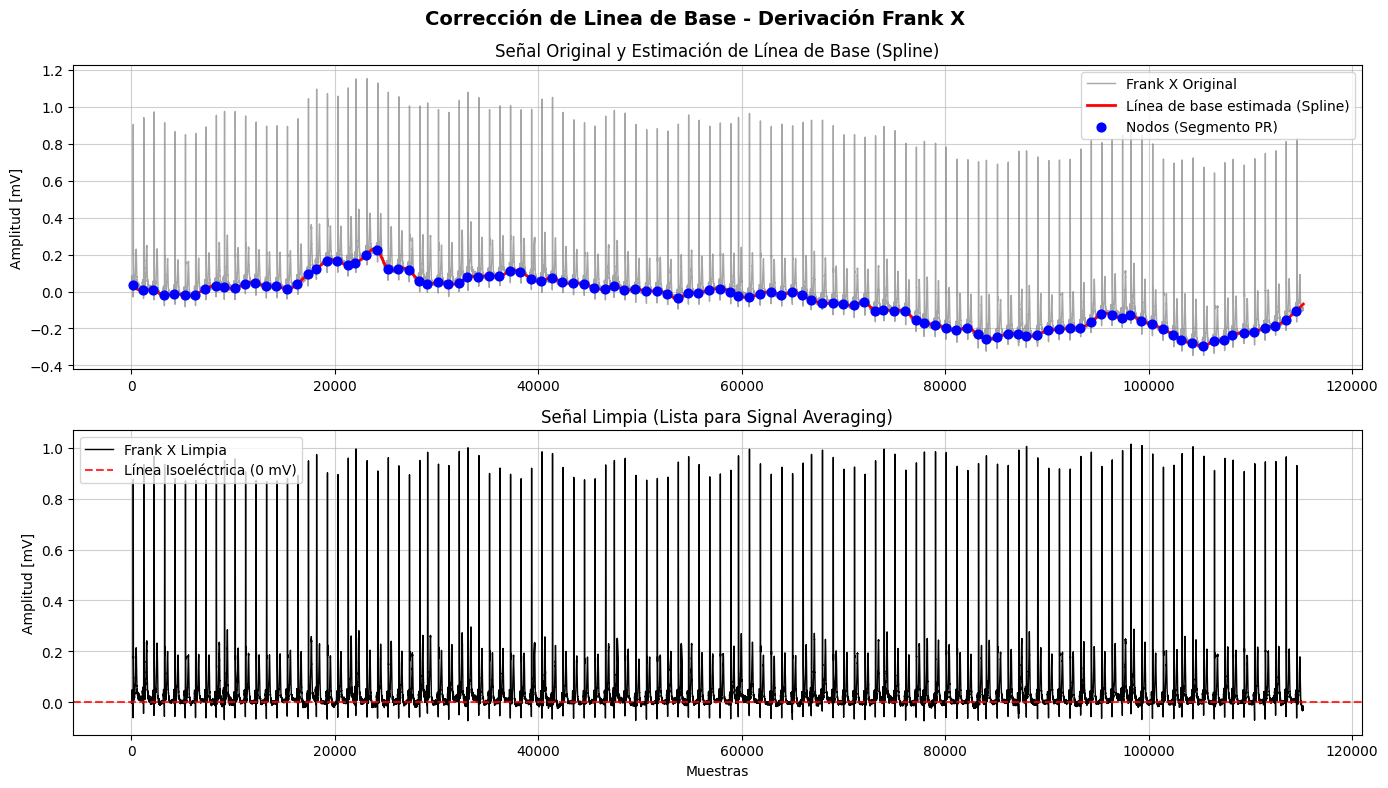

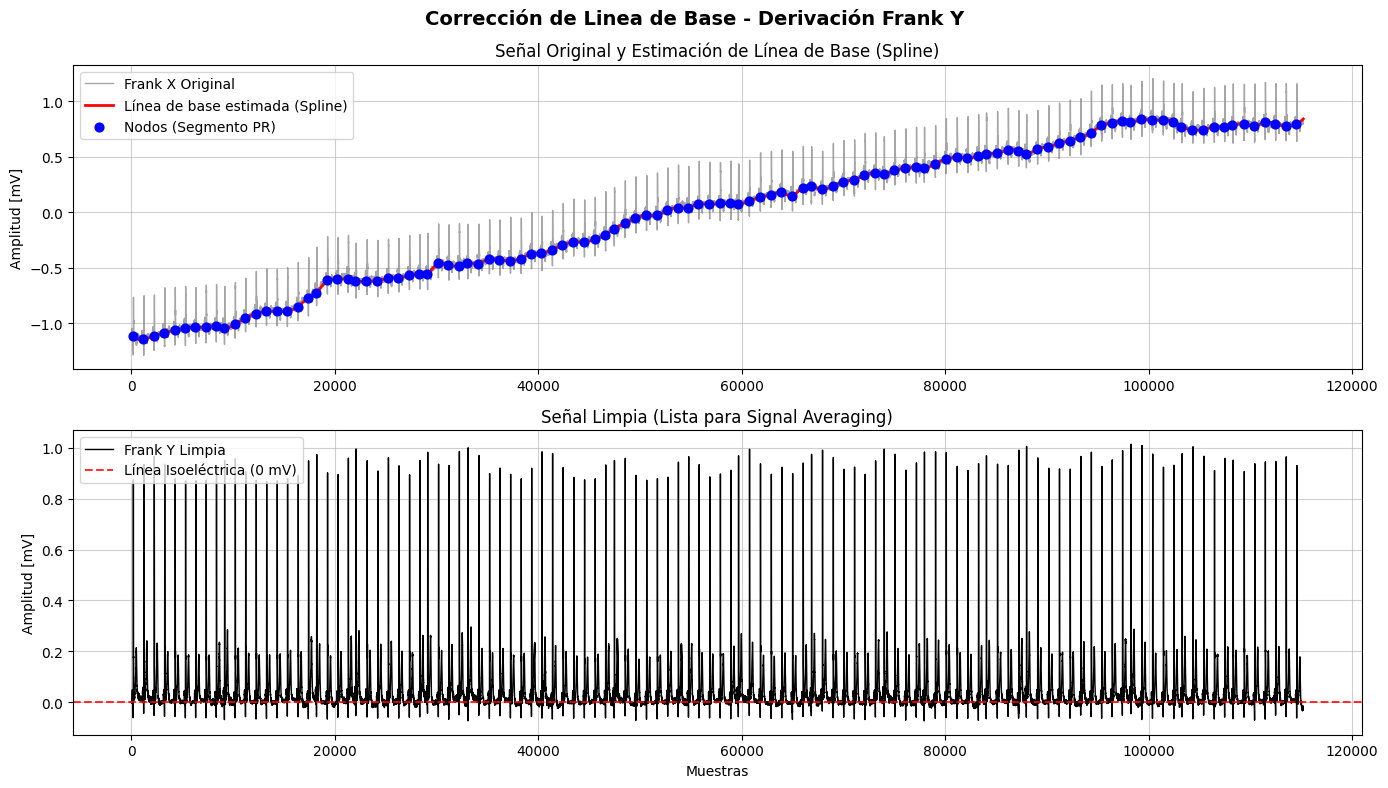

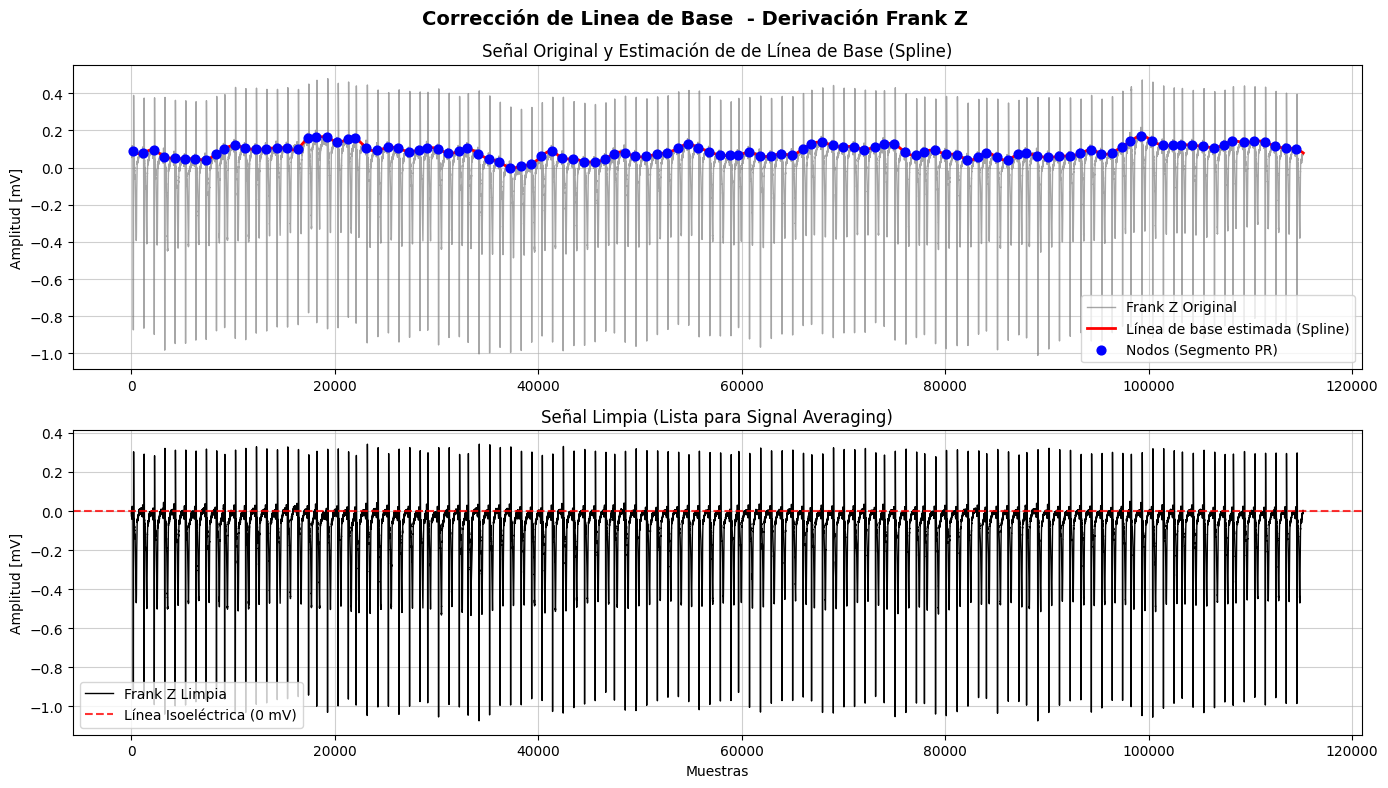

In [12]:

frank_x_clean, baseline_x, nodos_x = func.remover_linea_base_spline(frank_x, peaks_finales)
frank_y_clean, baseline_y, nodos_y = func.remover_linea_base_spline(frank_y, peaks_finales)
frank_z_clean, baseline_z, nodos_z = func.remover_linea_base_spline(frank_z, peaks_finales)

plt.figure(figsize=(14, 8))
plt.suptitle(f'Corrección de Linea de Base - Derivación Frank X', fontsize=14, fontweight='bold', y=0.98)

plt.subplot(2, 1, 1)
plt.title('Señal Original y Estimación de Línea de Base (Spline)', fontsize=12)
plt.plot(frank_x, color='gray', alpha=0.7, label='Frank X Original', linewidth=1)
plt.plot(baseline_x, color='red', linewidth=2, label='Línea de base estimada (Spline)')

#puntos isoelectricos
plt.scatter(nodos_x, frank_x[nodos_x], color='blue', s=40, zorder=5, label='Nodos (Segmento PR)')

plt.legend()
plt.ylabel('Amplitud [mV]')
plt.grid(True, alpha=0.6)

plt.subplot(2, 1, 2)
plt.title('Señal Limpia (Lista para Signal Averaging)', fontsize=12)
plt.plot(frank_x_clean, color='black', label='Frank X Limpia', linewidth=1)
plt.axhline(0, color='red', linestyle='--', alpha=0.8, label='Línea Isoeléctrica (0 mV)')

plt.xlabel('Muestras')
plt.ylabel('Amplitud [mV]')
plt.legend()
plt.grid(True, alpha=0.6)

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 8))
plt.suptitle(f'Corrección de Linea de Base - Derivación Frank Y', fontsize=14, fontweight='bold', y=0.98)

plt.subplot(2, 1, 1)
plt.title('Señal Original y Estimación de Línea de Base (Spline)', fontsize=12)
plt.plot(frank_y, color='gray', alpha=0.7, label='Frank X Original', linewidth=1)
plt.plot(baseline_y, color='red', linewidth=2, label='Línea de base estimada (Spline)')
plt.legend()
#puntos isoelectricos
plt.scatter(nodos_y, frank_y[nodos_y], color='blue', s=40, zorder=5, label='Nodos (Segmento PR)')

plt.ylabel('Amplitud [mV]')
plt.grid(True, alpha=0.6)
plt.legend()

plt.subplot(2, 1, 2)
plt.title('Señal Limpia (Lista para Signal Averaging)', fontsize=12)
plt.plot(frank_x_clean, color='black', label='Frank Y Limpia', linewidth=1)
plt.axhline(0, color='red', linestyle='--', alpha=0.8, label='Línea Isoeléctrica (0 mV)')

plt.xlabel('Muestras')
plt.ylabel('Amplitud [mV]')
plt.legend()
plt.grid(True, alpha=0.6)

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 8))
plt.suptitle(f'Corrección de Linea de Base  - Derivación Frank Z', fontsize=14, fontweight='bold', y=0.98)

plt.subplot(2, 1, 1)
plt.title('Señal Original y Estimación de de Línea de Base (Spline)', fontsize=12)
plt.plot(frank_z, color='gray', alpha=0.7, label='Frank Z Original', linewidth=1)
plt.plot(baseline_z, color='red', linewidth=2, label='Línea de base estimada (Spline)')

#puntos isoelectricos
plt.scatter(nodos_z, frank_z[nodos_z], color='blue', s=40, zorder=5, label='Nodos (Segmento PR)')

plt.ylabel('Amplitud [mV]')
plt.grid(True, alpha=0.6)
plt.legend()

plt.subplot(2, 1, 2)
plt.title('Señal Limpia (Lista para Signal Averaging)', fontsize=12)
plt.plot(frank_z_clean, color='black', label='Frank Z Limpia', linewidth=1)
plt.axhline(0, color='red', linestyle='--', alpha=0.8, label='Línea Isoeléctrica (0 mV)')

plt.xlabel('Muestras')
plt.ylabel('Amplitud [mV]')
plt.legend()
plt.grid(True, alpha=0.6)

plt.tight_layout()
plt.show()


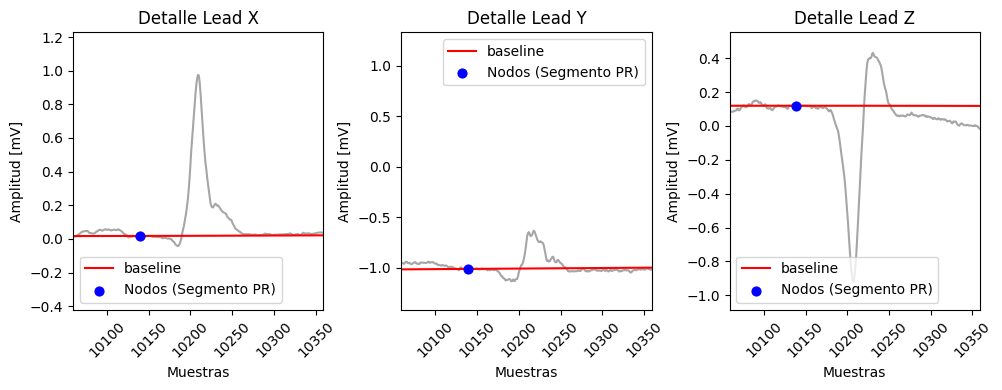

In [13]:
#DETALLES

#para que funcione con cualquier archivo
numero_de_latido = 10 
pico_central = peaks_finales[numero_de_latido]

muestras_atras_ventana = 150
muestras_adelante_ventana = 150

inicio_ventana = pico_central - muestras_atras_ventana
fin_ventana = pico_central + muestras_adelante_ventana

plt.figure(figsize=(10,4))
plt.subplot(1, 3, 1)
plt.title('Detalle Lead X', fontsize=12)
plt.plot(frank_x, color='gray', alpha=0.7)
plt.plot(baseline_x, color='red', label='baseline')
plt.scatter(nodos_x, frank_x[nodos_x], color='blue', s=40, zorder=5, label='Nodos (Segmento PR)')
plt.ylabel('Amplitud [mV]')
plt.xlim([inicio_ventana, fin_ventana])
plt.xticks(rotation=45)
plt.xlabel('Muestras')
plt.legend()

plt.subplot(1, 3, 2)
plt.title('Detalle Lead Y', fontsize=12)
plt.plot(frank_y, color='gray', alpha=0.7)
plt.plot(baseline_y, color='red', label='baseline')
plt.scatter(nodos_y, frank_y[nodos_y], color='blue', s=40, zorder=5, label='Nodos (Segmento PR)')
plt.ylabel('Amplitud [mV]')
plt.xlim([inicio_ventana, fin_ventana]) 
plt.xticks(rotation=45)
plt.xlabel('Muestras')
plt.legend()

plt.subplot(1,3,3)
plt.title('Detalle Lead Z', fontsize=12)
plt.plot(frank_z, color='gray', alpha=0.7)
plt.plot(baseline_z, color='red', label='baseline')
plt.scatter(nodos_z, frank_z[nodos_z], color='blue', s=40, zorder=5, label='Nodos (Segmento PR)')
plt.ylabel('Amplitud [mV]')
plt.xlim([inicio_ventana, fin_ventana]) 
plt.xticks(rotation=45)
plt.xlabel('Muestras')
plt.legend()

plt.tight_layout()
plt.show()

Una vez corregida la linea de base, se procede a seleccionar los latidos aptos para el promedidado y posterior obtención del vector de magnitud. 
La selección se realizó en primera instancia diseñando un "template" de latido a partir del cálculo de la mediana de la señal en un intervalo temporal de interés establecido en relación a los picos R. 

Se utiliza la mediana por ser una herramienta más robusta que el promedio, ya que no considera los valores atípicos de la señal para el intervalo de interés.

In [14]:
def template_mediana(senal, picos, ventana_atras_ms, ventana_adelante_ms, fs=1000):
    muestras_atras = int(ventana_atras_ms * fs / 1000)
    muestras_adelante = int(ventana_adelante_ms * fs / 1000)
    
    latidos_recortados = []
    
    for p in picos:
        inicio = p - muestras_atras
        fin = p + muestras_adelante
        
        if inicio >= 0 and fin < len(senal):
            recorte = senal[inicio:fin]
            latidos_recortados.append(recorte)
                
    #Conversión de la lista a matriz 
    matriz_latidos = np.array(latidos_recortados)
    
    template_mediana = np.median(matriz_latidos, axis=0)
    
    return template_mediana, matriz_latidos


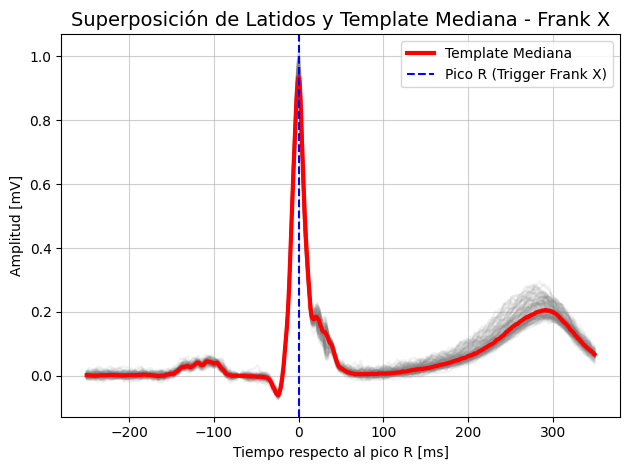

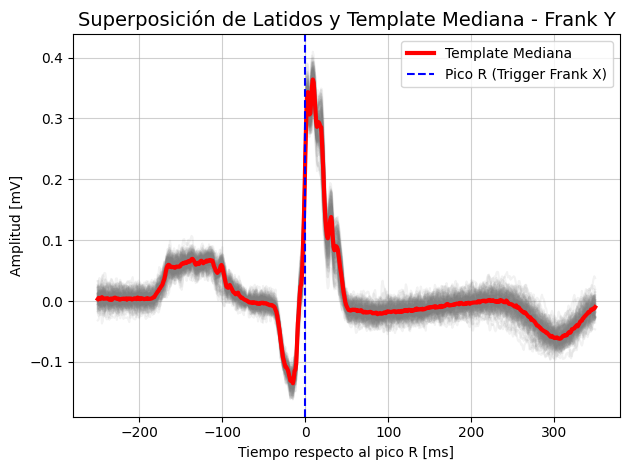

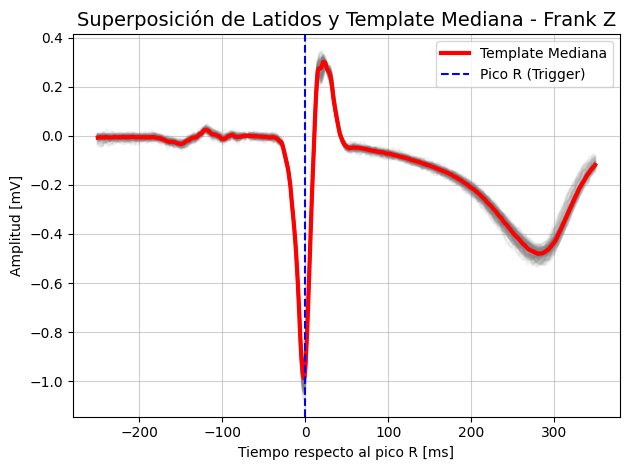

In [27]:
#cálculo de templates
ventana_atras = 250
ventana_adelante = 350   #ver

template_x, matriz_x = func.template_mediana(frank_x_clean, peaks_finales, ventana_atras, ventana_adelante)
template_y, matriz_y = func.template_mediana(frank_y_clean, peaks_finales, ventana_atras, ventana_adelante)
template_z, matriz_z = func.template_mediana(frank_z_clean, peaks_finales, ventana_atras, ventana_adelante)

# Eje de tiempo para el gráfico (en milisegundos, con el 0 en el pico R del lead X)
tiempo_template = np.arange(-ventana_atras, ventana_adelante) 

plt.figure()
plt.title('Superposición de Latidos y Template Mediana - Frank X', fontsize=14)

for i in range(matriz_x.shape[0]):
    plt.plot(tiempo_template, matriz_x[i, :], color='gray', alpha=0.1)

#grafico molde de mediana
plt.plot(tiempo_template, template_x, color='red', linewidth=3, label='Template Mediana')

#pico R
plt.axvline(0, color='blue', linestyle='--', label='Pico R (Trigger Frank X)')

plt.xlabel('Tiempo respecto al pico R [ms]')
plt.ylabel('Amplitud [mV]')
plt.legend()
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()


plt.figure()
plt.title('Superposición de Latidos y Template Mediana - Frank Y', fontsize=14)
for i in range(matriz_y.shape[0]): 
    plt.plot(tiempo_template, matriz_y[i, :], color='gray', alpha=0.1)

plt.plot(tiempo_template, template_y, color='red', linewidth=3, label='Template Mediana')
plt.axvline(0, color='blue', linestyle='--', label='Pico R (Trigger Frank X)')

plt.xlabel('Tiempo respecto al pico R [ms]')
plt.ylabel('Amplitud [mV]')
plt.legend()
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

plt.figure()
plt.title('Superposición de Latidos y Template Mediana - Frank Z', fontsize=14)
for i in range(matriz_z.shape[0]):
    plt.plot(tiempo_template, matriz_z[i, :], color='gray', alpha=0.1)
plt.plot(tiempo_template, template_z, color='red', linewidth=3, label='Template Mediana')
plt.axvline(0, color='blue', linestyle='--', label='Pico R (Trigger)')

plt.xlabel('Tiempo respecto al pico R [ms]')
plt.ylabel('Amplitud [mV]')
plt.legend()
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

#cada fila es un latido completo, cada columna un instante de tiempo!

Se observan los templates obtenidos para cada Frank Lead en rojo. Cabe destacar que se obtiene un template por Lead Frank, ya que la señal eléctrica difiere morfológicamente en cada uno de ellos. Sin embargo, el trigger sigue proviniendo del Lead X (Línea vertical azul). De esta forma, se toma como referencia la misma muestra para un latido en todos los leads, lo que permitirá calcular de manera correcta el Vector de Magnitud. 

Una vez que se cuenta con los templates, se utilizan en el algoritmo que decidirá si un latido deberá ser considerado para el promedio o no. 

In [28]:
def latidos_a_promediar(matriz_x, template_x, matriz_y, template_y, matriz_z, template_z):
    latidos_x = []
    latidos_y = []
    latidos_z = []
    
    num_latidos = matriz_x.shape[0]
    anterior_ok = True
    
    for i in range(num_latidos):
        latido_actual_x = matriz_x[i, :]
        correlacion_latido_x = np.corrcoef(latido_actual_x, template_x)[0, 1]
        latido_actual_y = matriz_y[i, :]
        correlacion_latido_y = np.corrcoef(latido_actual_y, template_y)[0, 1]
        latido_actual_z = matriz_z[i, :]
        correlacion_latido_z = np.corrcoef(latido_actual_z, template_z)[0, 1]

        actual_ok = correlacion_latido_x > 0.98 and correlacion_latido_y > 0.98 and correlacion_latido_z > 0.98
        
        if actual_ok and anterior_ok:
            latidos_x.append(latido_actual_x)
            latidos_y.append(latido_actual_y)
            latidos_z.append(latido_actual_z)
            
        anterior_ok = actual_ok #asi avanzo
        
    return latidos_x, latidos_y, latidos_z

Con la funcion anterior, se calcula la correlación de Pearson, ya que la misma toma en cuenta únicamente la morfología de la señal y no tendrá en cuenta variaciones que puedan deberse a motivos fisiológicos (respiración, etc.) y se pide que supere el 98%, según lo dispuesto por el paper de referencia. Aunque haya latidos que difieran en amplitud, si la morfología sigue cumpliendo el requisito en cuanto al template seguirá siendo elegible para promediar. Serán descartados aquellos latidos que difieran en cuanto a la forma de la señal, provocados por arritmias o anomalías, y además se descarta el siguiente a un latido no apto. 

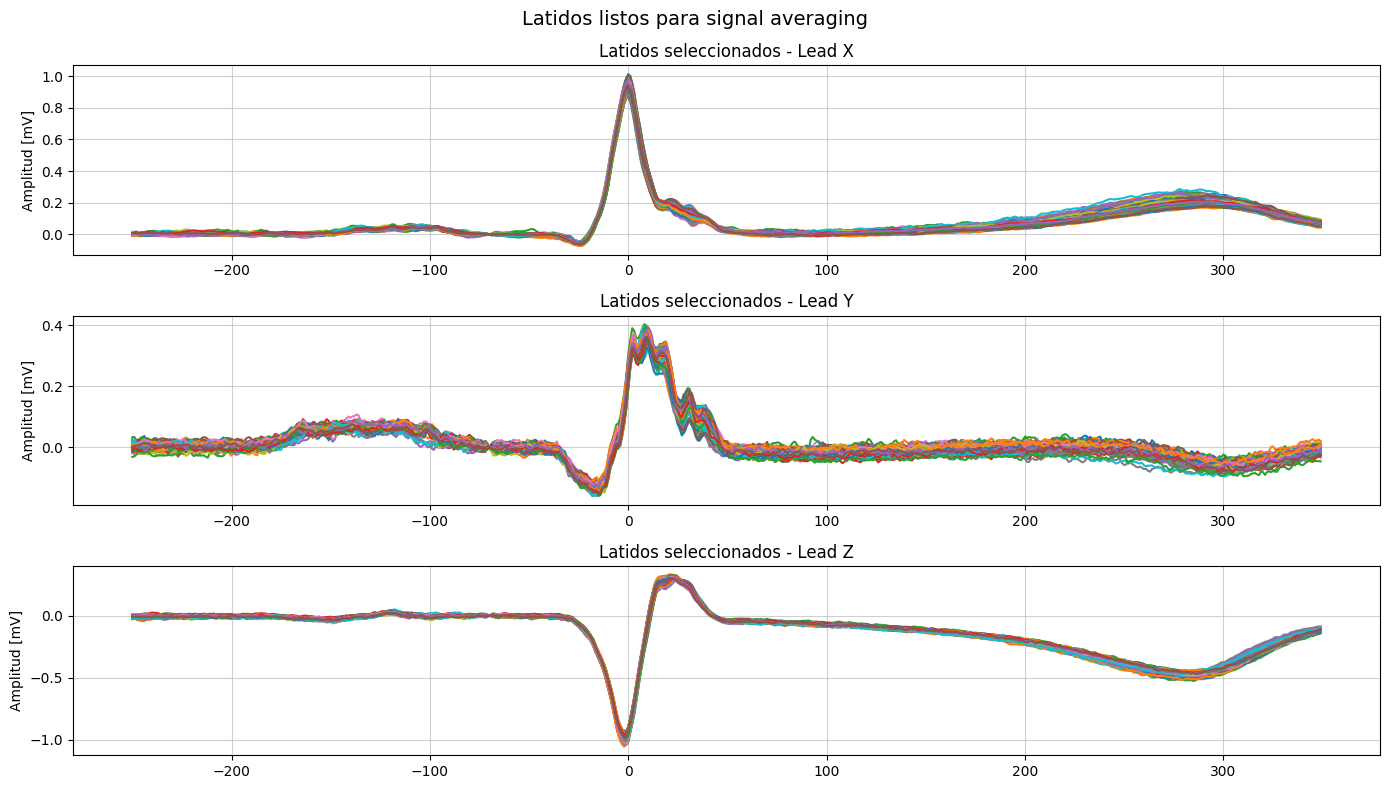

In [29]:
latidos_x, latidos_y, latidos_z = func.latidos_a_promediar(matriz_x, template_x, matriz_y, template_y, matriz_z, template_z)
    
plt.figure(figsize=(14, 8))
plt.suptitle('Latidos listos para signal averaging', fontsize=14)

#latidos_x es una lista

plt.subplot(3, 1, 1)
plt.title('Latidos seleccionados - Lead X')
for latido in latidos_x:
    plt.plot(tiempo_template, latido)
plt.ylabel('Amplitud [mV]')
plt.grid(True, alpha=0.6)

plt.subplot(3, 1, 2)
plt.title('Latidos seleccionados - Lead Y')
for latido in latidos_y:
    plt.plot(tiempo_template, latido)
plt.ylabel('Amplitud [mV]')
plt.grid(True, alpha=0.6)

plt.subplot(3, 1, 3)
plt.title('Latidos seleccionados - Lead Z')
for latido in latidos_z:
    plt.plot(tiempo_template, latido)
plt.ylabel('Amplitud [mV]')
plt.grid(True, alpha=0.6)

plt.tight_layout()
plt.show()

Se promedian los latidos que cumplieron las condiciones estipuladas anteriormente. Para que el resultado obtenido sea valido es necesario promediar entre 50 y 300 latidos 

In [30]:
def signal_averaging(latidos_x, latidos_y, latidos_z):

    average_x = np.average(latidos_x, axis=0)
    average_y = np.average(latidos_y, axis=0)
    average_z = np.average(latidos_z, axis=0)
    
    return average_x, average_y, average_z

Latidos exitosos promediados: 86


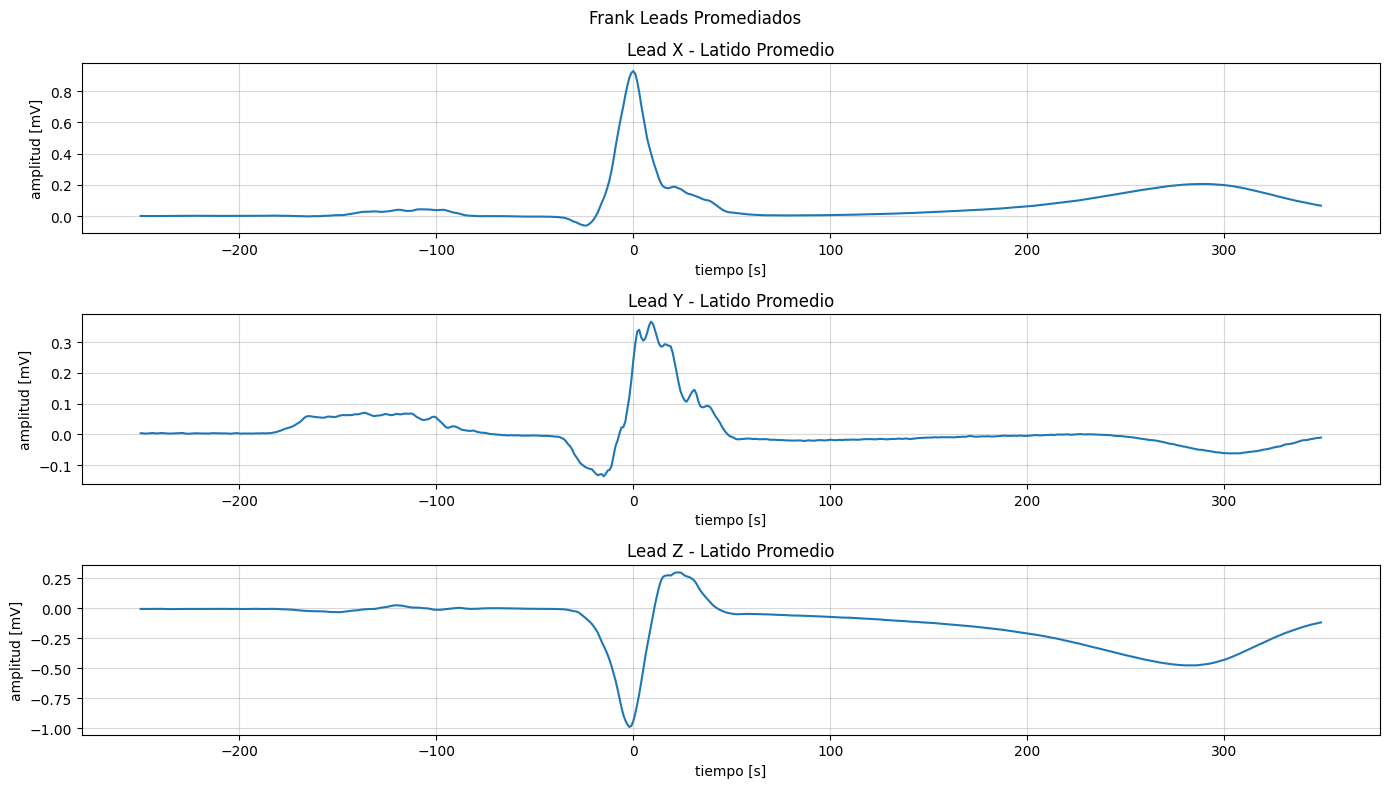

In [31]:
average_x, average_y, average_z = func.signal_averaging(latidos_x, latidos_y, latidos_z)    
print(f"Latidos exitosos promediados: {len(latidos_x)}")

plt.figure(figsize=(14, 8))
plt.suptitle('Frank Leads Promediados')

plt.subplot(3, 1, 1)
plt.plot(tiempo_template, average_x)
plt.ylabel('amplitud [mV]')
plt.xlabel('tiempo [s]')
plt.title('Lead X - Latido Promedio')
plt.grid(True, alpha=0.5)

plt.subplot(3, 1, 2)
plt.plot(tiempo_template, average_y)
plt.ylabel('amplitud [mV]')
plt.xlabel('tiempo [s]')
plt.title('Lead Y - Latido Promedio')
plt.grid(True, alpha=0.5)

plt.subplot(3, 1, 3)
plt.plot(tiempo_template, average_z)
plt.ylabel('amplitud [mV]')
plt.xlabel('tiempo [s]')
plt.grid(True, alpha=0.5)
plt.title('Lead Z - Latido Promedio')
plt.tight_layout()
plt.show()

Se continúa por aplicar un filtro pasabanda Butterworth de 4to bidireccional orden sobre las señales correspondientes a los latidos promedio de cada lead

In [32]:
#Butterworth bidireccional, 4to orden, 40-250Hz

def filtrado_butter_average(average_x, average_y, average_z,  low_cutoff, fs=1000):
    sos_avg = signal.butter(4, [low_cutoff, 250], btype='bp', analog=False, output='sos', fs=fs)
    
    avg_ff_x = signal.sosfiltfilt(sos_avg, average_x)
    avg_ff_y = signal.sosfiltfilt(sos_avg, average_y)
    avg_ff_z = signal.sosfiltfilt(sos_avg, average_z)
    
    return avg_ff_x, avg_ff_y, avg_ff_z

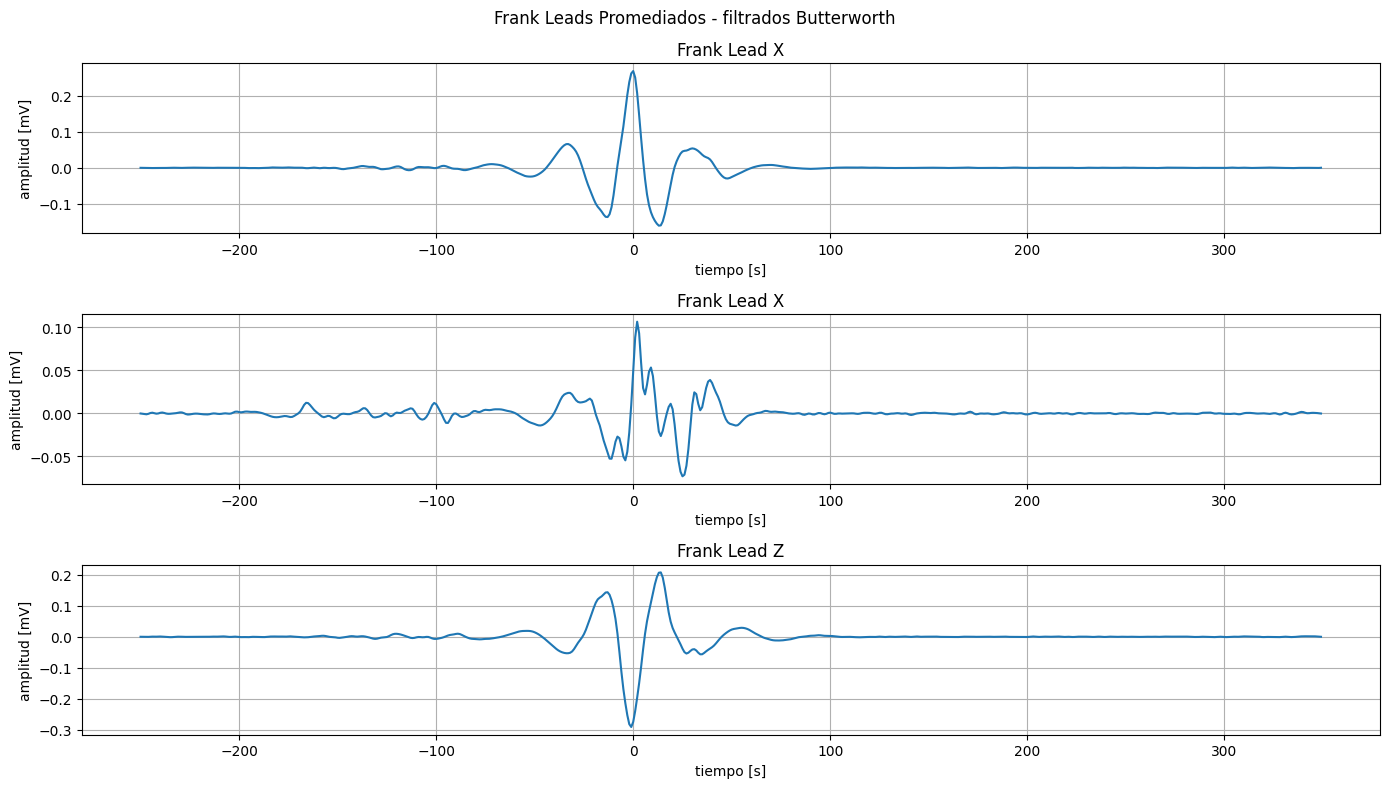

In [33]:
low_cutoff = 25 #VER!
avg_ff_x, avg_ff_y, avg_ff_z = func.filtrado_butter_average(average_x, average_y, average_z, low_cutoff)

plt.figure(figsize=(14, 8))
plt.suptitle('Frank Leads Promediados - filtrados Butterworth')

plt.subplot(3, 1, 1)
plt.title('Frank Lead X')
plt.plot(tiempo_template, avg_ff_x)
plt.ylabel('amplitud [mV]')
plt.xlabel('tiempo [s]')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.title('Frank Lead X')
plt.plot(tiempo_template, avg_ff_y)
plt.ylabel('amplitud [mV]')
plt.xlabel('tiempo [s]')
plt.grid(True)

plt.subplot(3, 1, 3)
plt.title('Frank Lead Z')
plt.plot(tiempo_template, avg_ff_z)
plt.ylabel('amplitud [mV]')
plt.xlabel('tiempo [s]')
plt.grid(True)

plt.tight_layout()
plt.show()

Concluido el procesamiento de la señal de interés, se calcula el Vector de Magnitud que engloba la energía de los 3 leads en un único valor para cada instante. A partir de éste se calculan también los 3 parámetros necesarios para determinar si existen VLPs.

Nota: El fin del segmento QRS se determina como "el punto medio de un segmento de 5 ms en el cual el voltaje promedio excede el nivel de ruido promedio más tres veces el desvío estándar de la muestra de ruido". 

Se toma una muestra de ruido al final de la señal "vm", y se hallan el inicio y fin del segmento QRS. 

In [34]:
def vector_magnitude(avg_ff_x, avg_ff_y, avg_ff_z):
    vm = np.sqrt(avg_ff_x**2 + avg_ff_y**2 + avg_ff_z**2)
    return vm

In [35]:
vm = func.vector_magnitude(avg_ff_x, avg_ff_y, avg_ff_z)
punto_fin_qrs, punto_inicio_qrs, duracion_qrs, segmento_qrs, ruido_tp = func.determinar_qrs(vm, low_cutoff)
rms40 = func.RMS40(punto_fin_qrs, vm)

In [38]:
#Determinacion duracion complejo QRS
def determinar_qrs(vm, low_cutoff, fs=1000):
    #muestra ruido - ultimas muestras 
    ruido_tp = vm[400:500] #VER
    
    rms_ruido_tp = np.sqrt(np.mean(ruido_tp**2))
    
    umbral = np.average(ruido_tp) + max(3 * np.std(ruido_tp), 0.002) #se agrega un minimo para evitar que sea demasiado sensible
    segmento = int(5*fs/1000)    
    
    punto_final_qrs = 0 
    punto_inicial_qrs = 0

    for i in range(400, 0, -1):
        ventana = vm[i : i + segmento]
        media_ventana = np.mean(ventana)
        if media_ventana > umbral:
            punto_final_qrs = i + (segmento // 2)
            break 
            
#hago lo mismo para determinar inicio
    for p in range(190, 400, 1): #VER RANGO PARA DETERMINAR INICIO
        ventana = vm[p : p + segmento]
        media_ventana = np.mean(ventana)
        if media_ventana > umbral:
            punto_inicial_qrs = p + (segmento // 2)
            break 
            
    duracion_qrs = punto_final_qrs - punto_inicial_qrs #recordar hacer calculo segun fs
    segmento_qrs = vm[punto_inicial_qrs:punto_final_qrs]
    
    return punto_final_qrs, punto_inicial_qrs, duracion_qrs, segmento_qrs, rms_ruido_tp


def comprobacion_ruido(segmento_qrs, fs=1000):
    #calculo RMS root mean square
    rms40 = np.sqrt(np.mean(segmento_qrs**2))
    return rms40


def RMS40(punto_fin_qrs, vm, fs=1000):
    #calculo RMS root mean square
    #necesito ultimos 40ms
    seg_40 = vm[punto_fin_qrs - 40 : punto_fin_qrs]
    rms40 = np.sqrt(np.mean(seg_40**2))
    return rms40

def LAS40(punto_fin_qrs, punto_inicial_qrs, vm, fs=1000):
    LAS40 = 0 
    for i in range(punto_fin_qrs, punto_inicial_qrs, -1):
        amplitud = vm[i]
        if amplitud > 0.04:
            return LAS40
        else:
            LAS40 = LAS40 + 1 
    return LAS40 

Se establece el nivel de ruido aceptable, dependiente de la frecuencia de corte inferior, según las referencias utilizadas

Nivel de ruido: 0.000758 mV
ruido aceptable


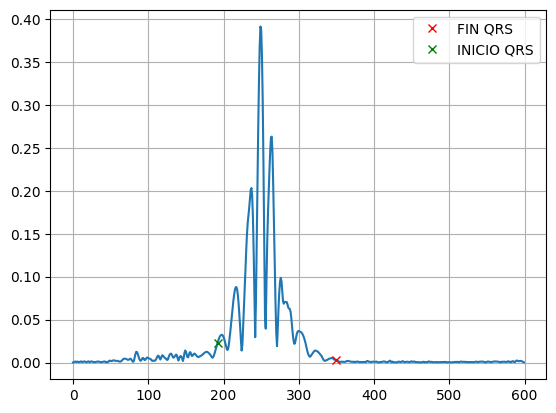

Duración QRS = 158 ms  [ANORMAL] - Duración esperada en pacientes sanos < 114ms
Valor RMS40  = 8.8 microV [ANORMAL] - Valor esperado en pacientes sanos > 20microV
Valor LAS40  = 59 ms      [ANORMAL] - Duración esperada en pacientes sanos >38ms
------------------------------
Criterios anormales detectados: 3/3
POSITIVO para Potenciales Ventriculares Tardíos


In [37]:
print(f"Nivel de ruido: {ruido_tp:.6f} mV")
if low_cutoff == 25:
    if ruido_tp < 0.001:
        print("ruido aceptable")
    else: 
        print("ADVERTENCIA RUIDO")
elif low_cutoff == 40:
    if ruido_tp < 0.0007:
        print("ruido aceptable")
    else: 
        print("ADVERTENCIA RUIDO")
    
plt.figure()
plt.plot(vm)
plt.plot(punto_fin_qrs, vm[punto_fin_qrs],'x', color = 'red', label = 'FIN QRS')
plt.plot(punto_inicio_qrs, vm[punto_inicio_qrs],'x', color = 'green', label = 'INICIO QRS')
plt.legend()
plt.grid(True)
plt.show()

LAS40 = func.LAS40(punto_fin_qrs, punto_inicio_qrs, vm)

criterios_anormales = 0

if duracion_qrs > 114:
    print(f"Duración QRS = {duracion_qrs} ms  [ANORMAL] - Duración esperada en pacientes sanos < 114ms")
    criterios_anormales += 1
else:
    print(f"Duración QRS = {duracion_qrs} ms  [NORMAL]")
    
if rms40 < 0.020:
    print(f"Valor RMS40  = {rms40 * 1000:.1f} microV [ANORMAL] - Valor esperado en pacientes sanos > 20microV")
    criterios_anormales += 1
else:
    print(f"Valor RMS40  = {rms40 * 1000:.1f} microV [NORMAL]")

if LAS40 > 38:
    print(f"Valor LAS40  = {LAS40} ms      [ANORMAL] - Duración esperada en pacientes sanos >38ms")
    criterios_anormales += 1
else:
    print(f"Valor LAS40  = {LAS40} ms      [NORMAL]")
    
print("-" * 30)
print(f"Criterios anormales detectados: {criterios_anormales}/3")

if criterios_anormales >= 2:
    print("POSITIVO para Potenciales Ventriculares Tardíos")
else:
    print("NEGATIVO (Valores normales)")

**Referencias**
- https://www.scielo.org.ar/scielo.php?script=sci_arttext&pid=S0327-07932009000300012&lng=es&nrm=iso
- https://www.ahajournals.org/doi/epdf/10.1161/01.CIR.83.4.1481
- https://peterhcharlton.github.io/bsp-book/tutorial/notebooks/qrs-detection.html
- https://ccrma.stanford.edu/~jos/fp/Linear_Phase_Filters_Symmetric_Impulse.html
- https://www.robots.ox.ac.uk/~gari/teaching/cdt/A3/readings/ECG/Pan+Tompkins.pdf